In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Softmax, Multiply, Lambda
from tensorflow.keras.models import Model

In [ ]:
# Parameters
DATA_PATH   = Path("/content/drive/MyDrive/Colab Notebooks/final-data-2022.csv") # <-- change path
LOOK_BACK   = 2          # number of past months fed to the model
TEST_START = "2024-11-01"
TEST_END    = "2025-02-01"  # final month in the dataset
VAL_START   = "2024-07-01"  # first month excluded from training (serves as val/test)
BATCH_SIZE  = 64
EPOCHS      = 100
MODEL_PATH  = Path("lsoa_burglary_lstm.h5")
n_features  = 31

In [ ]:
# Loading and sorting data

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
assert (df["Date"].dt.day == 1).all(), "Date column should be first day of month"

df.sort_values(["LSOA code", "Date"], inplace=True)
df

,LSOA code,Date,crime_count,Falls_within,LSOA_name,Year,Month,local authority code,local authority name,All usual residents aged 16 or over,...,Environment,Health,Housing,IDACI,IDAOPI,IMD,Income,Area,Population,Density
13058,E01000001,2022-07-01,1,Metropolitan Police Service,City of London 001A,2022,7,E09000001,City of London,1356,...,31.873,-1.654,29.472,0.006,0.012,6.208,0.007,0.1298,1795,13828.967643
26054,E01000001,2023-01-01,1,Metropolitan Police Service,City of London 001A,2023,1,E09000001,City of London,1356,...,31.873,-1.654,29.472,0.006,0.012,6.208,0.007,0.1298,1795,13828.967643
71750,E01000001,2024-10-01,1,Metropolitan Police Service,City of London 001A,2024,10,E09000001,City of London,1356,...,31.873,-1.654,29.472,0.006,0.012,6.208,0.007,0.1298,1795,13828.967643
74005,E01000001,2024-11-01,1,Metropolitan Police Service,City of London 001A,2024,11,E09000001,City of London,1356,...,31.873,-1.654,29.472,0.006,0.012,6.208,0.007,0.1298,1795,13828.967643
0,E01000002,2022-01-01,1,Metropolitan Police Service,City of London 001B,2022,1,E09000001,City of London,1301,...,23.084,-1.115,24.412,0.037,0.030,5.143,0.034,0.2283,1671,7319.316689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74004,E01004765,2024-10-01,10,Metropolitan Police Service,Westminster 013D,2024,10,E09000033,Westminster,1718,...,51.200,-0.564,24.699,0.188,0.189,18.728,0.112,0.2681,1918,7154.046997
76296,E01004765,2024-11-01,6,Metropolitan Police Service,Westminster 013D,2024,11,E09000033,Westminster,1718,...,51.200,-0.564,24.699,0.188,0.189,18.728,0.112,0.2681,1918,7154.046997
78586,E01004765,2024-12-01,10,Metropolitan Police Service,Westminster 013D,2024,12,E09000033,Westminster,1718,...,51.200,-0.564,24.699,0.188,0.189,18.728,0.112,0.2681,1918,7154.046997
80811,E01004765,2025-01-01,16,Metropolitan Police Service,Westminster 013D,2025,1,E09000033,Westminster,1718,...,51.200,-0.564,24.699,0.188,0.189,18.728,0.112,0.2681,1918,7154.046997


In [ ]:
# Ensure continuous monthly timeline per LSOA (zero‑fill missing months)

all_months = pd.date_range(df["Date"].min(), df["Date"].max(), freq="MS")

filled_frames = []
for lsoa, grp in df.groupby("LSOA code"):
    grp = grp.set_index("Date")
    grp = grp.reindex(all_months)            # new rows for missing months
    grp["LSOA code"] = lsoa                 # re‑add identifier
    grp["crime_count"].fillna(0, inplace=True)

    # Forward/backward fill static socio‑economic columns (rarely change monthly)
    static_cols = [
        "Falls_within", "LSOA_name", "local authority code", "local authority name",
        'All usual residents aged 16 or over',
        'Economically active: Employee: Full-time',
        'Economically active: Employee: Part-time',
        'Economically active: Full-time student',
        'Economically active: Self-employed with employees: Full-time',
        'Economically active: Self-employed with employees: Part-time',
        'Economically active: Self-employed without employees: Full-time',
        'Economically active: Self-employed without employees: Part-time',
        'Economically active: Unemployed',
        'Economically inactive: Long-term sick or disabled',
        'Economically inactive: Looking after home or family',
        'Economically inactive: Other', 'Economically inactive: Retired',
        'Economically inactive:  Full-time students',
        'Crime', 'Education', 'Employment', 'Environment', 'Health',
        'Housing', 'IDACI', 'IDAOPI', 'IMD', 'Income', 'Area',
        'Population', 'Density'
    ]
    grp[static_cols] = grp[static_cols].ffill().bfill()

    # Reset index -> column Date, not "index"
    grp = grp.reset_index().rename(columns={"index": "Date"})
    filled_frames.append(grp)

# Combine & guarantee datetime dtype
df_filled = pd.concat(filled_frames, ignore_index=True)
df_filled["Date"] = pd.to_datetime(df_filled["Date"])

Streaming output truncated to the last 5000 lines.

  grp["crime_count"].fillna(0, inplace=True)
<ipython-input-22-675f01f52f68>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  grp["crime_count"].fillna(0, inplace=True)
<ipython-input-22-675f01f52f68>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [ ]:
# Feature engineering

# Temporal cyclic encoding of month
df_filled["month"] = df_filled["Date"].dt.month
df_filled["month_sin"] = np.sin(2 * np.pi * df_filled["month"] / 12)
df_filled["month_cos"] = np.cos(2 * np.pi * df_filled["month"] / 12)

# Lag features (past LOOK_BACK months of burglary counts)
for lag in range(1, LOOK_BACK + 1):
    df_filled[f"lag_{lag}"] = df_filled.groupby("LSOA code")["crime_count"].shift(lag)

# Drop initial rows without sufficient lag history
print("   ➜ Dropping rows with NaNs in lag features …")
df_filled.dropna(subset=[f"lag_{lag}" for lag in range(1, LOOK_BACK + 1)], inplace=True)

# Select features
static_feature_cols = [
    'All usual residents aged 16 or over',
    'Economically active: Employee: Full-time',
    'Economically active: Employee: Part-time',
    'Economically active: Full-time student',
    'Economically active: Self-employed with employees: Full-time',
    'Economically active: Self-employed with employees: Part-time',
    'Economically active: Self-employed without employees: Full-time',
    'Economically active: Self-employed without employees: Part-time',
    'Economically active: Unemployed',
    'Economically inactive: Long-term sick or disabled',
    'Economically inactive: Looking after home or family',
    'Economically inactive: Other', 'Economically inactive: Retired',
    'Economically inactive:  Full-time students',
    'Crime', 'Education', 'Employment', 'Environment', 'Health',
    'Housing', 'IDACI', 'IDAOPI', 'IMD', 'Income',
    'Area', 'Population', 'Density'
]
lag_cols = [f"lag_{lag}" for lag in range(1, LOOK_BACK + 1)]
seasonal_cols = ["month_sin", "month_cos"]

FEATURE_COLS = static_feature_cols + lag_cols + seasonal_cols
TARGET_COL   = "crime_count"

   ➜ Dropping rows with NaNs in lag features …


In [ ]:
# Chronological split: train / validation / test

df_train = df_filled[df_filled["Date"] <  VAL_START]
df_val   = df_filled[(df_filled["Date"] >= VAL_START) & (df_filled["Date"] < TEST_START)]
df_test  = df_filled[df_filled["Date"] >= TEST_START]

print(f"Train rows: {len(df_train):,}")
print(f"Val  rows: {len(df_val):,}")
print(f"Test rows: {len(df_test):,}\n")

Train rows: 126,056
Val  rows: 18,008
Test rows: 18,008



In [ ]:
# Scaling (fit on train only)

scaler = StandardScaler()
scaler.fit(df_train[FEATURE_COLS])


def build_sequences(source_df):
    xs, ys = [], []
    for _, area_df in source_df.groupby("LSOA code"):
        area_df = area_df.sort_values("Date")
        feats   = scaler.transform(area_df[FEATURE_COLS])
        target  = area_df[TARGET_COL].values
        for i in range(len(area_df) - LOOK_BACK):
            xs.append(feats[i : i + LOOK_BACK])
            ys.append(target[i + LOOK_BACK])
    return np.array(xs), np.array(ys)

X_train, y_train = build_sequences(df_train)
X_val,   y_val   = build_sequences(df_val)
X_test,  y_test  = build_sequences(df_test)

print("Sequences ready:")
for name, arr in zip(["Train", "Val", "Test"], [X_train, X_val, X_test]):
    print(f"   ▸ {name:5s}: {arr.shape}")

Sequences ready:
   ▸ Train: (117052, 2, 31)
   ▸ Val  : (9004, 2, 31)
   ▸ Test : (9004, 2, 31)


In [ ]:
# Check if train test is empty (had some problems you can ignore this)
if X_test.size == 0:
    raise ValueError(
        "Test set is empty – push TEST_START earlier or reduce LOOK_BACK."
    )

MODEL WITH EXPLAINABILITY

In [ ]:
inputs = Input(shape=(LOOK_BACK, n_features), name="seq")

# LSTM encoder – keep return_sequences=True so we have one hidden state per step
h_seq = LSTM(64, return_sequences=True, name="lstm_enc")(inputs)   # (B, T, 64)

# Attention scores per time-step
score   = Dense(32, activation="tanh")(h_seq)     # (B, T, 32)
score   = Dense(1,  use_bias=False)(score)        # (B, T, 1)
weights = Softmax(axis=1, name="attention")(score)   # (B, T, 1)  sum_t w_t = 1

# Context vector = weighted sum of hidden states
context = Multiply()([h_seq, weights])            # (B, T, 64)
context = Lambda(lambda x: tf.reduce_sum(x, axis=1))(context)  # (B, 64)

# Feed-forward head
x = Dropout(0.2)(context)
x = Dense(32, activation="relu")(x)
outputs = Dense(1,  name="regression")(x)

model = Model(inputs, outputs, name="Attentive_LSTM")
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="mse", metrics=["mae"])
model.summary()

Model: "Attentive_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, 2, 31)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_enc (LSTM)     │ (None, 2, 64)     │     24,576 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2, 32)     │      2,080 │ lstm_enc[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2, 1)      │         32 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention (Softmax) │ (None, 2, 1)      │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 2, 64)     │          0 │ lstm_enc[0][0],   │
│ (Multiply)          │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 64)        │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression (Dense)  │ (None, 1)         │         33 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,801 (112.50 KB)

 Trainable params: 28,801 (112.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(X_train.shape)

(117052, 2, 31)


In [ ]:
# Train

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 1.4181 - mae: 0.8257 - val_loss: 1.1135 - val_mae: 0.7789
Epoch 2/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.2428 - mae: 0.8150 - val_loss: 1.0963 - val_mae: 0.7884
Epoch 3/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 1.2564 - mae: 0.8162 - val_loss: 1.1004 - val_mae: 0.7807
Epoch 4/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.2000 - mae: 0.8043 - val_loss: 1.0856 - val_mae: 0.7847
Epoch 5/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 1.2005 - mae: 0.8030 - val_loss: 1.0871 - val_mae: 0.7832
Epoch 6/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 1.1990 - mae: 0.8038 - val_loss: 1.1052 - val_mae: 0.7944
Epoch 7/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 1.2131 - mae: 0.8083 - val_loss: 1.0906 - val_mae: 0.7786
Epoch 8/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.2065 - mae: 0.8071 - val_loss: 1.0862 - val_mae: 0.7785
Epoch 9/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - l

In [ ]:
results = {}

# Validation set  (if you have one)
if 'X_val' in globals():
    y_val_pred = model.predict(X_val, verbose=0).flatten()
    results["val_MAE"] = mean_absolute_error(y_val, y_val_pred)
    results["val_MSE"] = mean_squared_error(y_val, y_val_pred)

# Test set  (completely held-out)
y_test_pred = model.predict(X_test, verbose=0).flatten()
results["test_MAE"] = mean_absolute_error(y_test, y_test_pred)
results["test_MSE"] = mean_squared_error(y_test, y_test_pred)

display(pd.Series(results))

,0
val_MAE,0.784677
val_MSE,1.085644
test_MAE,0.797199
test_MSE,1.104232


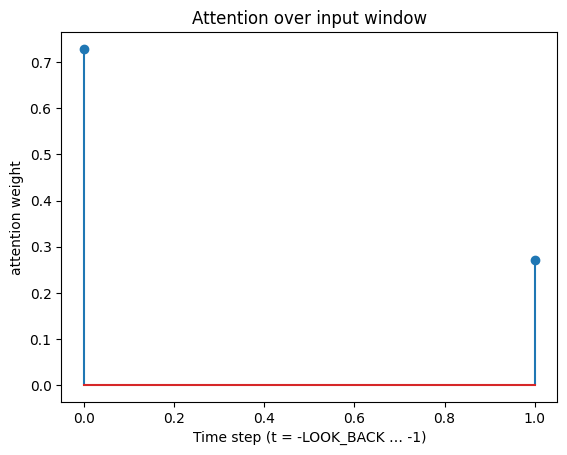

In [ ]:
# Built-in explainability: Attention weights

# Create a tiny model that just outputs the attention tensor
attn_extractor = Model(model.input, model.get_layer("attention").output)

sample_seq   = X_test[:1]                      # pick one sequence
attn_weights = attn_extractor(sample_seq)      # (1, T, 1) tensor

# Quick stem plot (optional visual check)
import matplotlib.pyplot as plt
plt.stem(attn_weights[0,:,0])
plt.xlabel("Time step (t = -LOOK_BACK … -1)")
plt.ylabel("attention weight")
plt.title("Attention over input window")
plt.show()

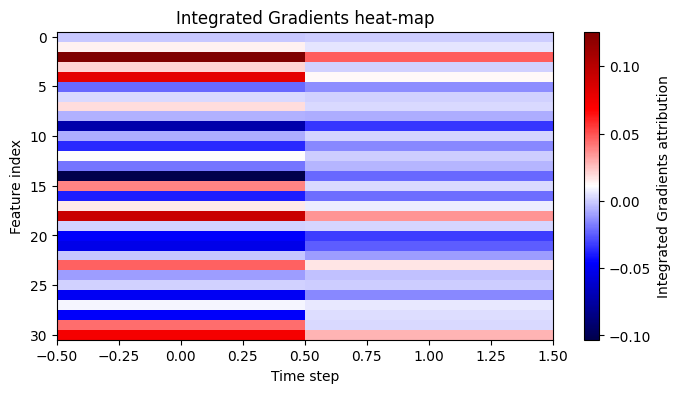

In [ ]:
# Post-hoc explainer #1  – Integrated Gradients

def integrated_gradients(model, inputs, baseline=None, steps=50):

    inputs   = tf.cast(inputs, tf.float32)
    if baseline is None:
        baseline = tf.zeros_like(inputs)
    else:
        baseline = tf.cast(baseline, tf.float32)

    # Interpolation coefficients
    alphas = tf.linspace(0.0, 1.0, steps + 1)

    # Collect gradients
    avg_grads = tf.zeros_like(inputs, dtype=tf.float32)

    for alpha in alphas:
        interp = baseline + alpha * (inputs - baseline)
        with tf.GradientTape() as tape:
            tape.watch(interp)
            preds = model(interp)                     # (1, 1)
        grads = tape.gradient(preds, interp)          # (1, T, F)
        avg_grads += grads

    avg_grads /= (steps + 1)
    ig_attribs = (inputs - baseline) * avg_grads      # (1, T, F)
    return ig_attribs

ig_attr = integrated_gradients(model, sample_seq, steps=50)  # (1,T,F)

# Heat-map: features (rows) × time-steps (cols)
plt.figure(figsize=(8, 4))
plt.imshow(ig_attr[0].numpy().T, aspect='auto', cmap='seismic',
           interpolation='nearest')
plt.colorbar(label="Integrated Gradients attribution")
plt.xlabel("Time step")
plt.ylabel("Feature index")
plt.title("Integrated Gradients heat-map")
plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

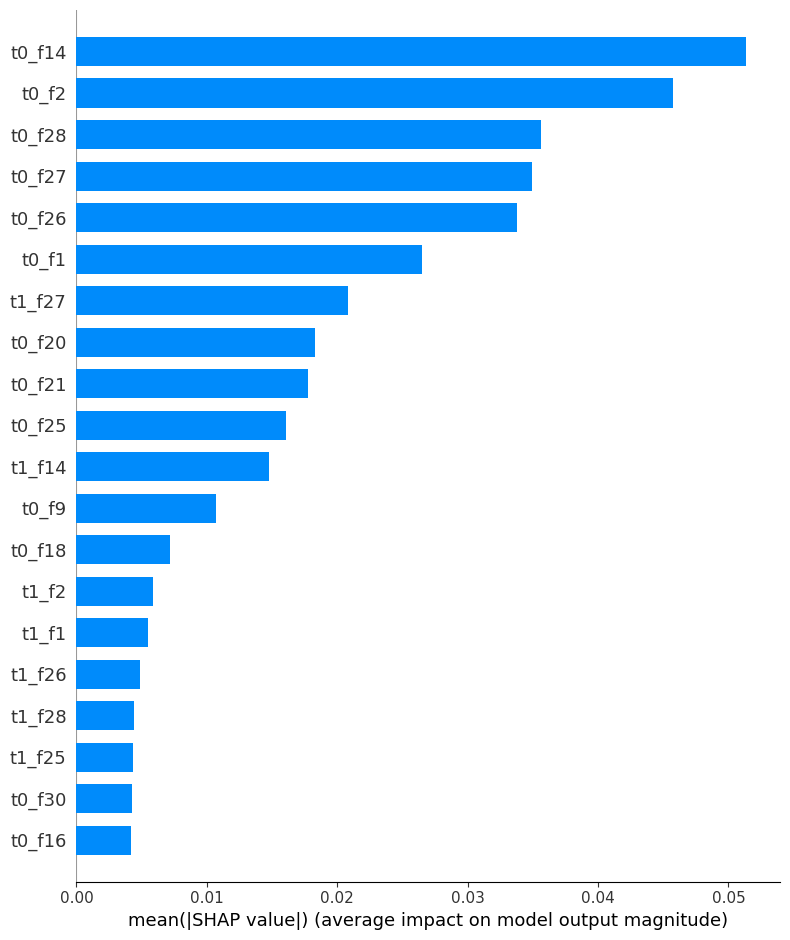

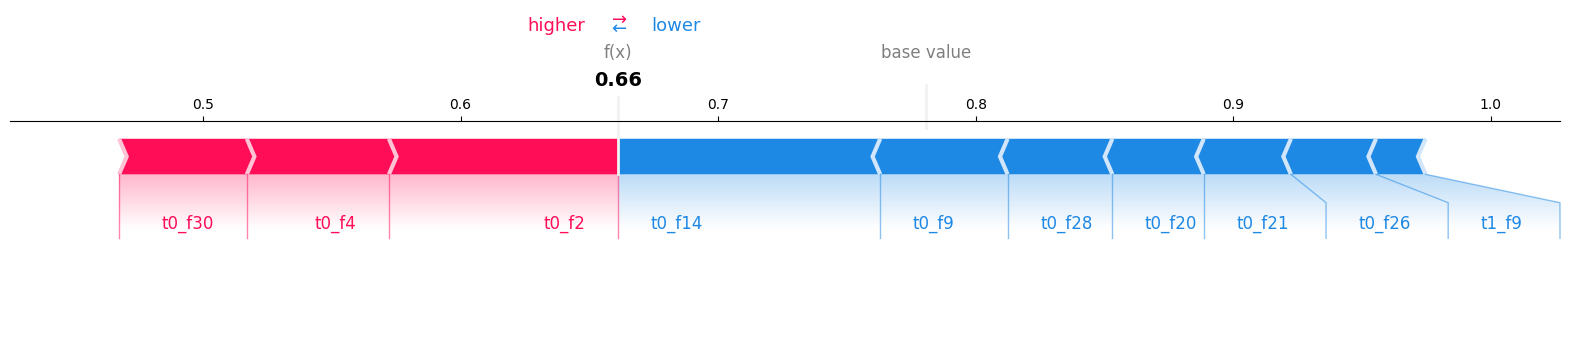

In [ ]:
# Post-hoc explainer #2  – SHAP DeepExplainer

import shap
# flatten helpers
def flatten(seq3d):
    """(N,T,F) → (N, T*F)"""
    return seq3d.reshape(seq3d.shape[0], -1)

def unflatten(mat2d):
    """(N, T*F) → (N,T,F)"""
    return mat2d.reshape(mat2d.shape[0], LOOK_BACK, n_features)

# Wrap model.predict so it accepts 2-D flattened input
def f(mat2d):
    return model(unflatten(mat2d)).numpy().flatten()

# Background and test data as 2-D matrices
background_2d = flatten(X_train[np.random.choice(len(X_train), 100, replace=False)])
test_2d       = flatten(X_test[:20])

explainer   = shap.KernelExplainer(f, background_2d)
shap_values = explainer.shap_values(test_2d, nsamples="auto")   # (20, T*F)

# Global summary (bar)
feature_names = [f"t{t}_f{f}" for t in range(LOOK_BACK) for f in range(n_features)]
shap.summary_plot(shap_values, test_2d, plot_type="bar", feature_names=feature_names)

# Local force plot for first sequence
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    matplotlib=True,
    feature_names=feature_names
)